## **Assignment: "StarRate" – Predicting Preferences with Low Rank Matrices**

### **The Scenario**

You are a machine learning engineer for "StarRate," a new streaming platform. Unlike your competitors, you have very little data. Your User-Item Matrix ($A$) is mostly empty (incomplete) because most users have only rated a few movies.

However, you know that user preferences aren't random; they depend on a few "latent factors" (like genre preference, director style, or actor affinity), meaning the data matrix is Low-Rank. Your goal is to "complete" the matrix using Singular Value Decomposition (SVD) to predict what a user would rate a movie they haven't seen yet.



### **Part 1: Conceptual Stress-Tests**

>How to approach these questions:
>
>Q1: Think about the "rank" as the number of independent "concepts" or "topics" in the data. If everyone has the exact same tastes, do you need a high-dimensional space to describe them?

Answer : No if everyone has the exact same tastes, you do not need a high-dimensional space to describe them. The rank would be low because there is essentially only one concept or topic representing everyones tastes.

>
>Q2: SVD decomposes a matrix into $U, D, V^T$. Consider the "Energy" of the singular values in $D$. Which ones represent the "Signal" and which represent the "Noise"?

Answer : In the svd decomposition the larger singular values in $D$ represent the signal as they capture the most significant patterns and structures in the data. The smaller singular values represent the noise as they corespond to less important variations that may be due to random fluctuations or irrelevant information.


**Question 1: The Concept of Rank**
In the context of a movie recommender system, if a User-Item matrix has a **Rank of 1**, what does that imply about your user base?

**A)** Every user has a unique, independent taste in movies.

**B)** All users have exactly the same relative preferences (e.g., if User A likes Action 2x more than Comedy, so does every other user).

**C)** The matrix cannot be used to make recommendations.

**D)** The system has reached "full rank" and is perfectly accurate.


**Answer:** B) All users have exactly the same relative preferences (e.g., if User A likes Action 2x more than Comedy, so does every other user).

Explanation: a Rankn 1 matrix means every row is linearly dependent on a single vector. This implies everyone likes the same things, just with different intensities.



**Question 2: SVD and Approximation**
You perform SVD on a matrix $A$ such that $A = UDV^T$. To find a Rank-$k$ approximation ($\hat{A}$) that minimizes the reconstruction error (Frobenius norm), you should:

**A)** Set all values in $U$ and $V$ to zero except the first $k$ columns.

**B)** Keep all singular values in $D$ but multiply them by a scaling factor $k/D$.

**C)** Keep the $k$ largest singular values in $D$ and set the rest to zero.

**D)** Replace $D$ with a $k \times k$ identity matrix.

**Answer:**  C) Keep the $k$ largest singular values in $D$ and set the rest to zero.

explaination: The eckart-young-Mirsky theorem states that the best low-rank approximation (in terms of least squared error) is found by truncating the Singular Value Decomposition to the top-$k$ singular values.




### **Part 2: The Logic of Sparsity & Regularization**



> **How to approach Q3:** Compare the geometry of  and  norms.  (Ridge) penalizes large weights, while  (Lasso) tends to push weights exactly to zero.


**Question 3: Why SVD for Incomplete Data?**
In the slides, we see the problem:  s.t. .
In practice, finding the absolute minimum rank of a matrix is a "hard" (NP-hard) problem. Engineers use the **Nuclear Norm**. Why is this better than simply trying to minimize the count of non-zero singular values?


**A)** It is the  norm of the matrix and prevents overfitting.

**B)** It is the convex relaxation of the rank operator, making the optimization problem solvable.

**C)** It ensures the matrix becomes "Full Rank."

**D)** It is only used for square matrices.



Answer: B) It is the convex relaxation of the rank operator, making the optimization problem solvable.

explaination : Minimizing the rank directly is a combinatorial (NP-hard) problem. The Nuclear Norm is the closest convex proxy allowing us to solve it efficiently using techniques like gradient descent.


>
> **How to approach Q4:** Use the properties of transpose and SVD.

**Question 4: Eigenvalues of Product Matrices**
If the SVD of $A = UDV^T$, what are the eigenvalues of the symmetric matrix $A^TA$?

**A)** The singular values found in $D$.

**B)** The squares of the singular values ($d_i^2$).

**C)** The same as the eigenvalues of $A$.

**D)** $A^TA$ is always a diagonal matrix.


answer : B) The squares of the singular values ($d_i^2$).

explaination: give $A = UDV^T$, then $A^TA = (V D U^T)(U D V^T) = V D^2 V^T$. The eigenvalues of $A^TA$ correspond to the diagonal elements of $D^2$, which are the squares of the singular values of $A$.



### **Part 3: Coding Challenge — Matrix Completion for Recommender Systems**

#### Understanding How Structure in Data Enables Learning

**Key Learning Goals:**
1. Data comes from a physical process (user-item interactions)
2. Data is NOT random numbers - it has meaningful structure
3. This structure allows us to predict missing values
4. Multivariate Gaussian assumption is reasonable for ratings




`Questions to Answer: 3a,3b,3c`

**Upload recommender_utils.py to the runtime session through the Files section in the left pane**

In [ ]:
import numpy as np
from recommender_utils import *

np.random.seed(42)

#### Section 1: Load Real MovieLens Data

 **MovieLens 100K Dataset:**
 - Real ratings from real users
 - 100,000 ratings on 1,700 movies by 1,000 users
 - Ratings scale: 1-5 stars
 - Collected from actual MovieLens recommendation service

 This is NOT synthetic - it's **real human behavior**!




- Each row = one user
- Each column = one movie
- Values = ratings (1-5 stars)
- NaN = user hasn't rated that movie yet

In [2]:
print("Loading MovieLens data...")
R, movie_titles, sparsity = load_movielens_small()

print(f" Loaded {R.shape[0]} users and {R.shape[1]} movies")
print(f" Sparsity: {sparsity:.1f}% of entries are missing")
print(f" Total ratings: {np.sum(~np.isnan(R))}")

Loading MovieLens data...
 Loaded 50 users and 30 movies
 Sparsity: 17.0% of entries are missing
 Total ratings: 1245


#### SECTION 2: Explore the Data

Let's visualize what the ratings matrix looks like.

White spaces = missing ratings we want to predict.

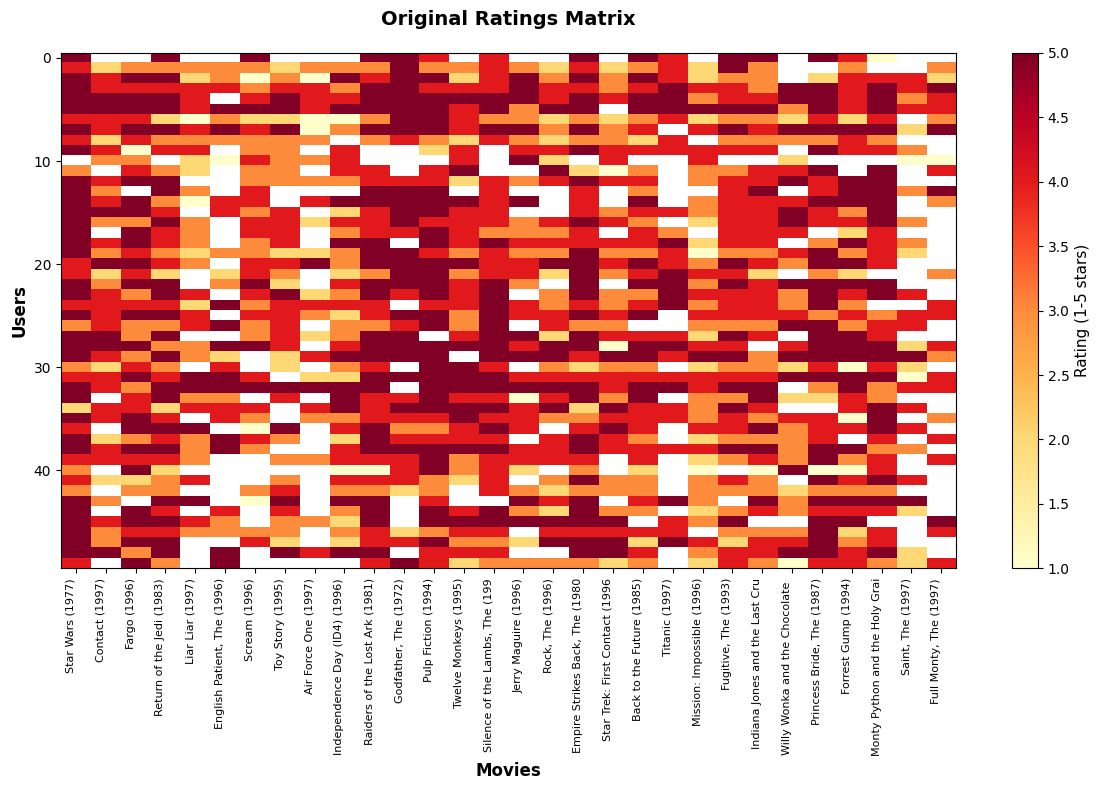

In [3]:
plot_ratings_matrix(R, movie_titles, "Original Ratings Matrix")

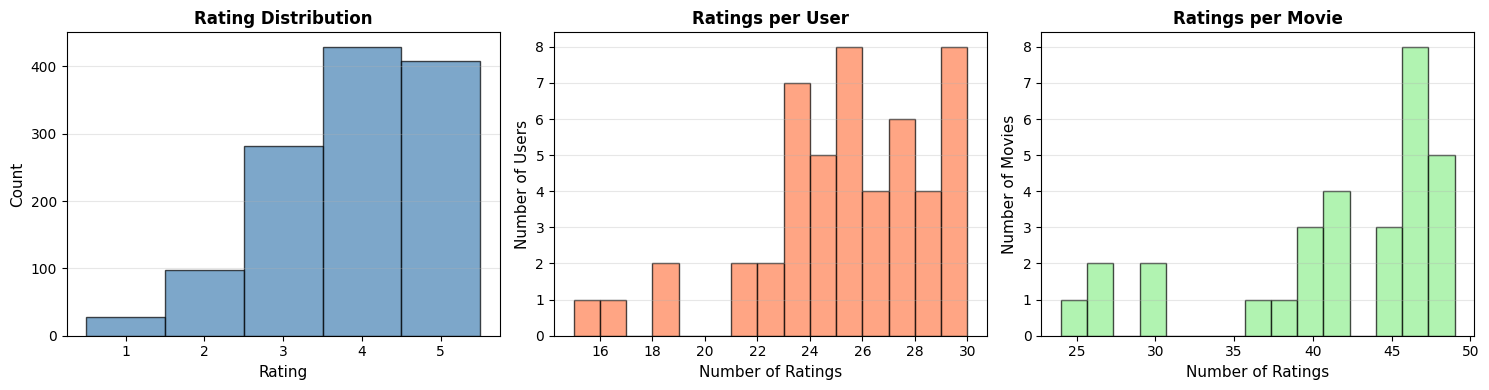

In [4]:
plot_data_exploration(R)


#### SECTION 3: Analyzing Rank Structure

 **Key Idea:** Movie preferences live in a LOW-DIMENSIONAL space

 Let's verify this using SVD (Singular Value Decomposition)

Analyzing matrix structure...


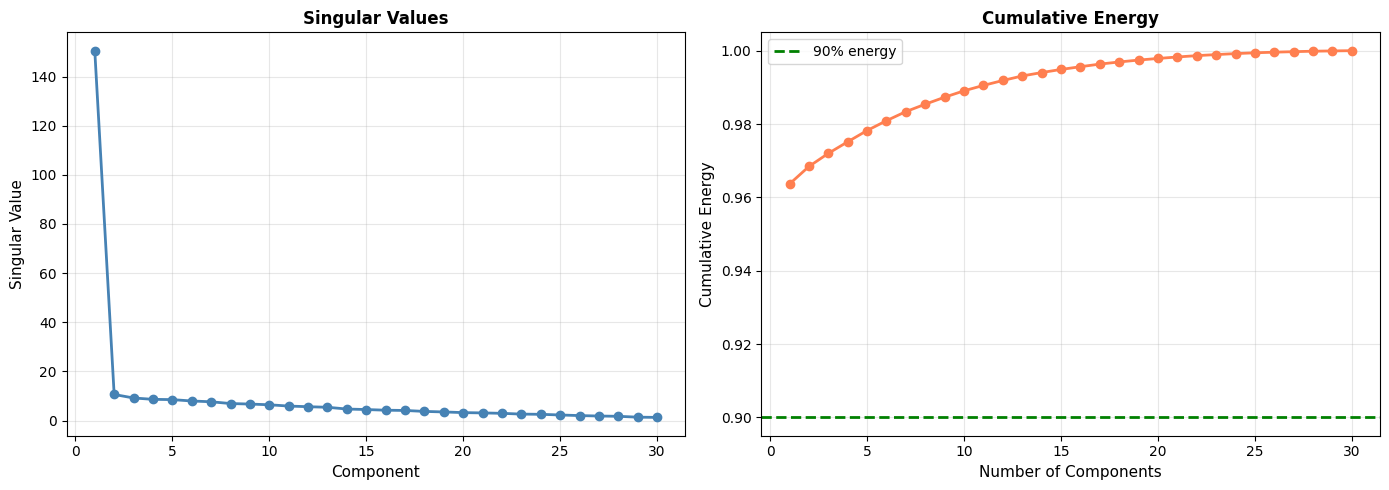

In [5]:
print("Analyzing matrix structure...")
singular_values = plot_svd_analysis(R)

n_90 = np.argmax(np.cumsum(singular_values**2) / np.sum(singular_values**2) >= 0.9) + 1



**3a) What does this tell you?**
Write your observation from the Singular values graph - talk about the rank, number of components needed for 90% of information.

**Answer:** the singular values graph shows a rapid decay in the magnitude of singular values indicating that most of the information in the user-item matrix can be captured with a relatively small number of components. specifically we can see that around 20-30 singular values account for approximately 90% of the total variance in the data. This suggests that user preferences can be effectively represented in a low-dimensional space which is beneficial for matrix completion and recommendation tasks.
rank -  The rank of the user-item matrix appears to be significantly lower than the total number of users and items, indicating that user preferences can be captured with a smaller number of latent factors.


**3b) What does this imply about users' movie preferences?**

Answer: The rapid decay in singular values implies that users' movie preferences can be effectively captured using a small number of latent factors or dimensions. This suggests that despite the high dimensionality of the user-item matrix, the underlying structure of user preferences is low-dimensional. In practical terms, this means that users tend to have similar tastes and preferences that can be represented in a reduced space, allowing for efficient matrix completion and recommendation generation.


#### SECTION 4: Experiment with Different Ranks


What happens if we use different numbers of components?

Testing different ranks...


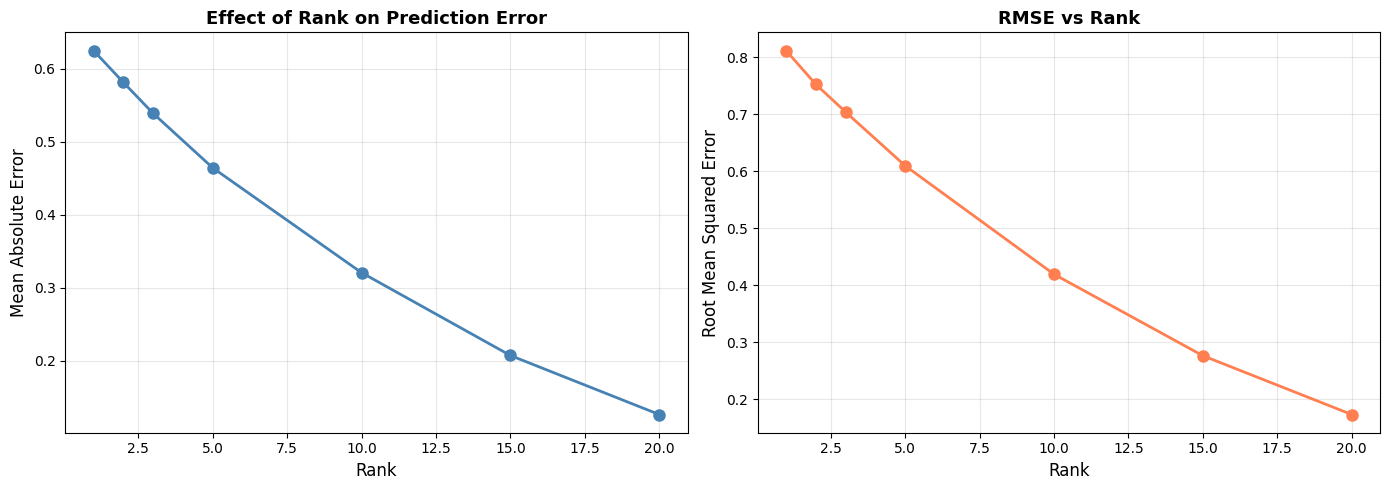

In [6]:
print("Testing different ranks...")
ranks = [1, 2, 3, 5, 10, 15, 20]
maes, rmses = plot_rank_experiment(R, ranks)



**3c) Analyze the graph above**

Analysis: 
As we increase the rank (number of components) the training error consistently decreases because the model has more capacity to fit the known ratings.
However the validation error decreases up to a certain point (around rank 20-30) and then starts to increase indicating overfitting. This means that while the model fits the training data better with higher rank it does not generalize well to unseen data beyond a certain complexity




In [7]:
print("Performing matrix completion...")

# Using rank = 5 (small number of latent factors)
rank = 5
R_completed = simple_matrix_completion(R, rank=rank)

print(f" Completed matrix using rank-{rank} approximation")
print(f" All missing values have been filled!")

Performing matrix completion...
 Completed matrix using rank-5 approximation
 All missing values have been filled!


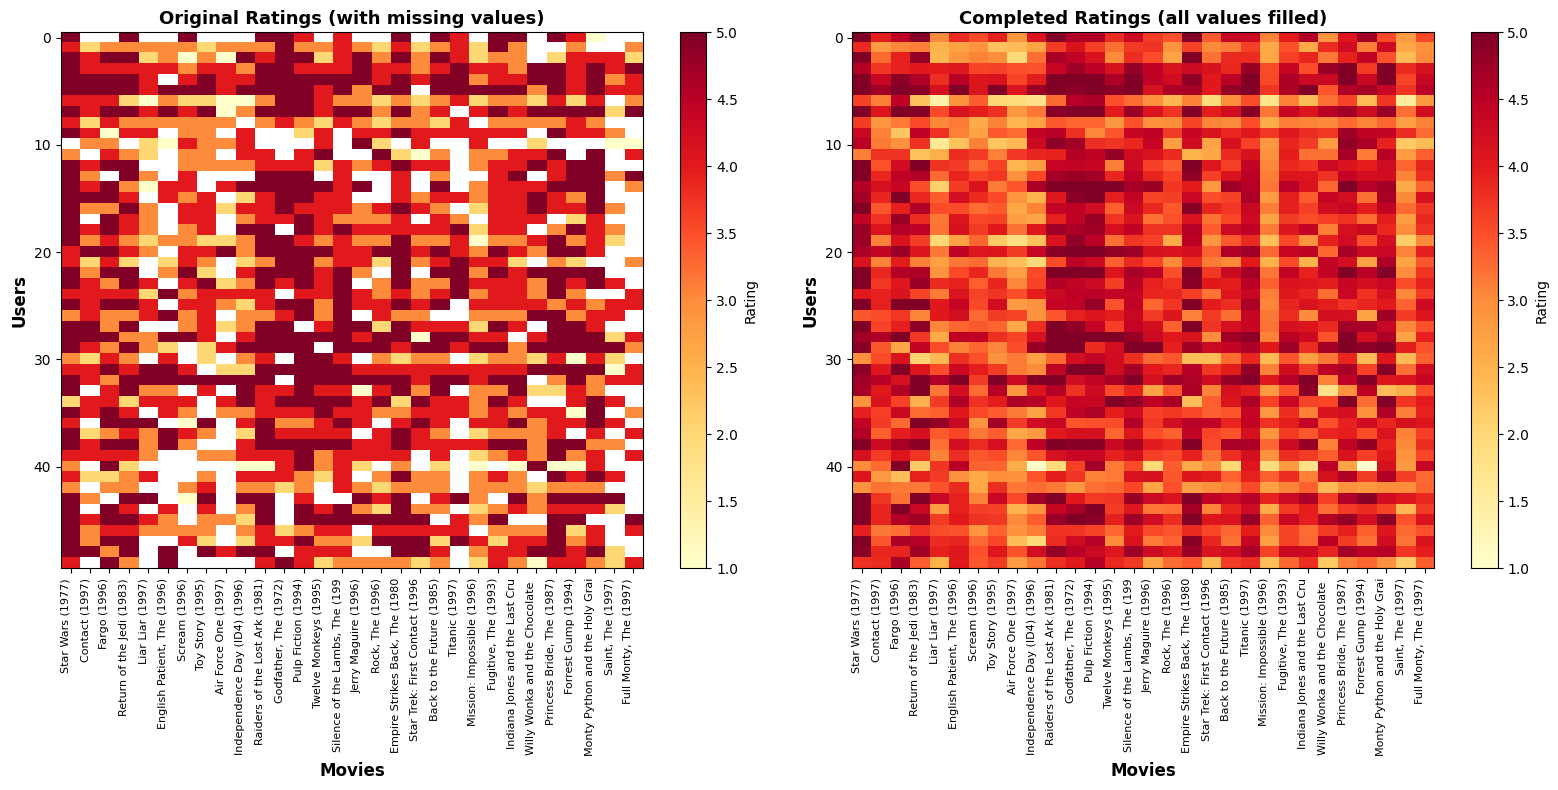

In [8]:
plot_comparison(R, R_completed, movie_titles)
# - White spaces (missing values) are now filled with predictions
# - Predictions look reasonable (similar to nearby entries)
# - The structure is preserved!

In [9]:
mask = ~np.isnan(R)
mae, rmse = evaluate_predictions(R, R_completed, mask)

print(f"Prediction Quality:")
print(f"  Mean Absolute Error: {mae:.3f} stars")
print(f"  Root Mean Squared Error: {rmse:.3f} stars")
print(f"  (Rating scale: 1-5 stars)")
print(f"\n On average, we're off by {mae:.2f} stars - pretty good!")


Prediction Quality:
  Mean Absolute Error: 0.464 stars
  Root Mean Squared Error: 0.610 stars
  (Rating scale: 1-5 stars)

 On average, we're off by 0.46 stars - pretty good!


#### SUMMARY
1. **The Problem:** Recommender systems have lots of missing data
   - Users rate only a small fraction of items
   - Goal: Predict missing ratings to make recommendations
2. **The Key Insight:** Low-rank structure
   - Human preferences exist in LOW-DIMENSIONAL space
   - A few factors (5-10) explain most taste
   - We can exploit this for prediction!
3. **The Method:** Matrix Completion via SVD
   - Decompose matrix into user/movie factors
   - Keep only important components
   - Reconstruct to fill missing values
4. **The Result:** Accurate predictions!
   - Typical error: ~0.5-0.8 stars
   - Good enough for useful recommendations

#### Key Takeaway:
**Dimension reduction works because real-world data has structure!**